## Original SIP loops (from authors) VS Mariner-fine-tuned SIP loops VS UnionLoops-fine-tuned SIP loops (Note: all same loci for a fair comparison of their precision)

SIP: 5kb loops <br>
Mariner fine-tuned SIP: for clustering: Manhattan distance, DBSCAN clustering, radius=10kb, pick max value (SIP metric ('APScoreAvg')) in one single sample per cluster) <br>
UionLoops (based on HiCCUPS): for clustering: Euclidean distance, clustering used by HiCCUPS, radius=20kb, pick max sum value (UnionLoops metric ('balanced counts')) across multiple samples per cluster)

### Generate mariner fine-tuned SIP loops

In [ ]:
# # Run on local laptop (R)
# #!/usr/bin/env Rscript


# # https://genome.cshlp.org/content/suppl/2023/09/12/gr.277397.122.DC1
# # https://genome.cshlp.org/content/suppl/2023/09/12/gr.277397.122.DC1/Supplemental_Code.zip
# # radius = 2, column = "APScoreAvg", same as ctcfLoops.R (2 bins radius)
# # analysis/ctcfLoops.R
# # R -q -e "library(mariner); packageVersion('mariner'); sessionInfo()"
# # conda env: mariner-r44
# # Four loop list from author email:
# # Subject: Questions about in situ Hi-C data during differentiation of K562 cells at 0, 6, and 72 h.

# library(mariner)

# file0    <- "K562_0h_SIP_5kbLoops.txt"
# file6    <- "K562_6h_SIP_5kbLoops.txt"
# file72   <- "K562_72h_SIP_5kbLoops.txt"
# fileMega <- "K562_Mega_SIP_5kbLoops.txt"


# # Read them in
# loops <- list(
#   read.table(file0,    header = TRUE),
#   read.table(file6,    header = TRUE),
#   read.table(file72,   header = TRUE),
#   read.table(fileMega, header = TRUE)
# )

# loops <- lapply(loops, function(df) {
#   # Convert to character (safe if numeric)
#   c1 <- as.character(df$chromosome1)
#   c2 <- as.character(df$chromosome2)
  
#   # Add "chr" only if not already present
#   df$chromosome1 <- ifelse(grepl("^chr", c1), c1, paste0("chr", c1))
#   df$chromosome2 <- ifelse(grepl("^chr", c2), c2, paste0("chr", c2))
  
#   return(df)
# })

# names(loops) <- c("0", "6", "72", "mega")

# # Assign row names
# for (i in 1:length(loops)){
#   loops[[i]]$name <- paste0("loop", 1:nrow(loops[[i]]))
# }

# # Convert to ginteractions: 
# loops <- lapply(loops, as_ginteractions)

# # Merge loops within 2 bins radius
# mp <-
#   mergePairs(x = loops,
#              radius=10e3, # 2*5kb resolution
#              column="APScoreAvg",
#              selectMax=TRUE)

# #get loops identified in at least each timepoint
# in0 <- subsetBySource(mp, include = "0")
# in6 <- subsetBySource(mp, include = "6")
# in72 <- subsetBySource(mp, include = "72")


# ## Export each subset as TSV (BEDPE-style + metadata)
# to_tsv <- function(x, file) {
#   df <- as.data.frame(x)
#   write.table(df, file = file, sep = "\t", quote = FALSE, row.names = FALSE)
# }

# to_tsv(in0,  "mariner_loops_in0.tsv")
# to_tsv(in6,  "mariner_loops_in6.tsv")
# to_tsv(in72, "mariner_loops_in72.tsv")

# ## extract corresponding clusters
# clusters=as.data.frame(getPairClusters(mp[1])[[1]])
# clusters$cluster_id=1
# for(i in 2:nrow(as.data.frame(mp))){
#   cluster_df=as.data.frame(getPairClusters(mp[i])[[1]])
#   cluster_df$cluster_id=i
#   clusters=rbind(clusters,cluster_df)
# }

# write.table(clusters, file = "mariner_clusters.tsv", sep = "\t", quote = FALSE, row.names = FALSE)

# ## Save sessionInfo to a single text file
# writeLines(capture.output(sessionInfo()), "sessionInfo.txt")

# # output files were saved to /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/SIP_5kb_from_authors/




# # sessionInfo.txt

# R version 4.4.3 (2025-02-28)
# Platform: x86_64-apple-darwin13.4.0
# Running under: macOS Big Sur ... 10.16

# Matrix products: default
# BLAS/LAPACK: /opt/miniconda3/envs/mariner-r44/lib/libopenblasp-r0.3.30.dylib;  LAPACK version 3.12.0

# locale:
# [1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

# time zone: America/New_York
# tzcode source: system (macOS)

# attached base packages:
# [1] stats     graphics  grDevices utils     datasets  methods   base     

# other attached packages:
# [1] mariner_1.6.0

# loaded via a namespace (and not attached):
#  [1] SummarizedExperiment_1.36.0 gtable_0.3.6               
#  [3] rjson_0.2.23                ggplot2_3.5.2              
#  [5] plyranges_1.26.0            rhdf5_2.50.0               
#  [7] Biobase_2.66.0              lattice_0.22-7             
#  [9] bitops_1.0-9                rhdf5filters_1.18.0        
# [11] vctrs_0.6.5                 tools_4.4.3                
# [13] generics_0.1.4              yulab.utils_0.2.1          
# [15] stats4_4.4.3                curl_7.0.0                 
# [17] parallel_4.4.3              tibble_3.3.0               
# [19] pkgconfig_2.0.3             Matrix_1.7-3               
# [21] data.table_1.17.8           ggplotify_0.1.2            
# [23] plotgardener_1.12.0         RColorBrewer_1.1-3         
# [25] S4Vectors_0.44.0            assertthat_0.2.1           
# [27] lifecycle_1.0.4             GenomeInfoDbData_1.2.13    
# [29] compiler_4.4.3              farver_2.1.2               
# [31] progress_1.2.3              Rsamtools_2.22.0           
# [33] Biostrings_2.74.0           codetools_0.2-20           
# [35] InteractionSet_1.34.0       GenomeInfoDb_1.42.0        
# [37] yaml_2.3.10                 RCurl_1.98-1.17            
# [39] pillar_1.11.0               crayon_1.5.3               
# [41] colourvalues_0.3.9          BiocParallel_1.40.0        
# [43] DelayedArray_0.32.0         dbscan_1.2.3               
# [45] abind_1.4-5                 tidyselect_1.2.1           
# [47] digest_0.6.37               purrr_1.1.0                
# [49] restfulr_0.0.16             dplyr_1.1.4                
# [51] grid_4.4.3                  colorspace_2.1-1           
# [53] cli_3.6.5                   SparseArray_1.6.0          
# [55] magrittr_2.0.3              S4Arrays_1.6.0             
# [57] XML_3.99-0.17               withr_3.0.2                
# [59] prettyunits_1.2.0           rappdirs_0.3.3             
# [61] UCSC.utils_1.2.0            scales_1.4.0               
# [63] XVector_0.46.0              httr_1.4.7                 
# [65] matrixStats_1.5.0           hms_1.1.3                  
# [67] HDF5Array_1.34.0            BiocIO_1.16.0              
# [69] GenomicRanges_1.58.0        IRanges_2.40.0             
# [71] rtracklayer_1.66.0          gridGraphics_0.5-1         
# [73] rlang_1.1.6                 Rcpp_1.1.0                 
# [75] glue_1.8.0                  BiocManager_1.30.26        
# [77] BiocGenerics_0.52.0         jsonlite_2.0.0             
# [79] strawr_0.0.92               R6_2.6.1                   
# [81] Rhdf5lib_1.28.0             GenomicAlignments_1.42.0   
# [83] MatrixGenerics_1.18.0       fs_1.6.6                   
# [85] zlibbioc_1.52.0            




### Generate UnionLoops-fined-tuned SIP loops
UnionLoops (v1.1.0) now supports merging loops from multiple datasets generated by external loop callers.

In [8]:
import pandas as pd
import numpy as np
import os
from matplotlib import pyplot as plt

In [13]:
# convert sip loop files to bedpe format
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min',
            'MEGA']

sip_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/SIP_5kb_from_authors/'
# original_sip
original_sip_files={'K562_0000min': sip_dir+'K562_0h_SIP_5kbLoops.txt',
                    'K562_0360min': sip_dir+'K562_6h_SIP_5kbLoops.txt',
                    'K562_4320min': sip_dir+'K562_72h_SIP_5kbLoops.txt',
                    'MEGA': sip_dir+'K562_Mega_SIP_5kbLoops.txt'}

output_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/SIP_5kb_from_authors/unionloops_v1.1.0/'
for cond in conditions:
    original_sip_df = pd.read_csv(
        original_sip_files[cond],
        usecols=range(6),
        header=0,
        sep='\t')
    original_sip_df.columns = ['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']
    original_sip_df['chrom1']='chr'+original_sip_df['chrom1']
    original_sip_df['chrom2']='chr'+original_sip_df['chrom2']
#     original_sip_df.to_csv(output_dir+os.path.basename(original_sip_files[cond]).replace(".txt", ".bedpe"), sep="\t", index=False, header=False)


In [15]:
# generate loop path
sip_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/SIP_5kb_from_authors/'
loops = {'name': ['K562_0000min',
                  'K562_0360min',
                  'K562_4320min',
                  'MEGA'],
         'path': [sip_dir + 'unionloops_v1.1.0/K562_0h_SIP_5kbLoops.bedpe',
                  sip_dir + 'unionloops_v1.1.0/K562_6h_SIP_5kbLoops.bedpe',
                  sip_dir + 'unionloops_v1.1.0/K562_72h_SIP_5kbLoops.bedpe',
                  sip_dir + 'unionloops_v1.1.0/K562_Mega_SIP_5kbLoops.bedpe'
                 ]}
loops = pd.DataFrame.from_dict(loops)

# loops.to_csv(sip_dir+'unionloops_v1.1.0/SIP_loop_paths_of_Bond_et_al_2023.tsv', sep='\t', index=False, header=True)


In [ ]:
# Run unionloops pipeline
# cd /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/SIP_5kb_from_authors/unionloops_v1.1.0
# bsub < run.sh


### Compare precision of original SIP loops (from authors) VS Mariner-fine-tuned SIP loops VS UnionLoops-fine-tuned SIP loops

In [22]:
import pickle
import bioframe
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
from matplotlib import pyplot as plt

In [23]:
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']

sip_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/SIP_5kb_from_authors/'
# original_sip
original_sip_files={'K562_0000min': sip_dir+'K562_0h_SIP_5kbLoops.txt',
                    'K562_0360min': sip_dir+'K562_6h_SIP_5kbLoops.txt',
                    'K562_4320min': sip_dir+'K562_72h_SIP_5kbLoops.txt'}

# mariner_sip
mariner_sip_files={'K562_0000min': sip_dir+'mariner_loops_in0.tsv',
                   'K562_0360min': sip_dir+'mariner_loops_in6.tsv',
                   'K562_4320min': sip_dir+'mariner_loops_in72.tsv'}
mariner_sip_clusters=pd.read_csv(sip_dir+'mariner_clusters.tsv', sep='\t')[['seqnames1','start1','end1','seqnames2','start2','end2','src','cluster_id']].rename({'seqnames1': 'chrom1', 'seqnames2': 'chrom2'}, axis='columns')

# UnionLoops_sip
dots_file=sip_dir+'unionloops_v1.1.0/results/Bond_et_al_2023_union_SIP_loop_list_5kb.tsv'
dots_new=pd.read_csv(dots_file, sep='\t')[['chrom1','start1','end1','chrom2','start2','end2','sample_name']]
# remove MEGA only loops
dots_new=dots_new.loc[dots_new.sample_name != 'MEGA']


In [24]:
# intersect original sip and unionloops first
# further intersect with mariner-sip loops
summary_loops={}
for cond in conditions:
    summary_loops[cond]={}
    # original sip
    original_sip_df = pd.read_csv(
        original_sip_files[cond],
        usecols=range(6),
        header=0,
        sep='\t')
    original_sip_df.columns = ['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']
    original_sip_df['chrom1']='chr'+original_sip_df['chrom1']
    original_sip_df['chrom2']='chr'+original_sip_df['chrom2']
    
    # mariner sip
    mariner_sip_df = pd.read_csv(
        mariner_sip_files[cond],
        usecols=[0,1,2,5,6,7],
        header=0,
        sep='\t')
    mariner_sip_df.columns = ['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']
    
    # unionloops sip
    dots_new_df=dots_new.loc[dots_new.sample_name.str.contains(cond)]
    
    summary_loops[cond]['original_sip']=original_sip_df
    summary_loops[cond]['mariner_sip']=mariner_sip_df
    summary_loops[cond]['unionloops_sip']=dots_new_df
    
    

In [25]:
# merged peak files CNR (two replicates)

CNR_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/cut_and_run/merged/'
ctcf_peak_file={
    'K562_0000min': CNR_dir+'MEGA_ChIP_CTCF_K562_WT_PMA_0_S_peaks.narrowPeak',
    'K562_0360min': CNR_dir+'MEGA_ChIP_CTCF_K562_WT_PMA_360_S_peaks.narrowPeak',
    'K562_4320min': CNR_dir+'MEGA_ChIP_CTCF_K562_WT_PMA_4320_S_peaks.narrowPeak'
}

# Note: K562_0360min does not have rad21 data
rad21_peak_file={
    'K562_0000min': CNR_dir+'MEGA_ChIP_Rad21_K562_WT_PMA_0_S_peaks.narrowPeak',
    'K562_4320min': CNR_dir+'MEGA_ChIP_Rad21_K562_WT_PMA_4320_S_peaks.narrowPeak'
}

atac_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/ATAC_Seq/merged/'
atac_peak_file={
    'K562_0000min': atac_dir+'MERGE_MEGA_ATAC_ATAC_K562_WT_PMA_0_S_peaks.narrowPeak',
    'K562_0360min': atac_dir+'MERGE_MEGA_ATAC_ATAC_K562_WT_PMA_360_S_peaks.narrowPeak',
    'K562_4320min': atac_dir+'MERGE_MEGA_ATAC_ATAC_K562_WT_PMA_4320_S_peaks.narrowPeak'
}



In [26]:
methods=['original_sip',
         'mariner_sip',
         'unionloops_sip']

all_anchors=[]
for cond in conditions:
    for method in methods:
        loops_df=summary_loops[cond][method][['chrom1','start1','end1','chrom2','start2','end2']].copy().reset_index(drop=True)
        anchor1=loops_df[['chrom1','start1','end1']].copy().set_axis(['chrom','start','end'], axis=1)
        anchor2=loops_df[['chrom2','start2','end2']].copy().set_axis(['chrom','start','end'], axis=1)
        anchors=pd.concat([anchor1, anchor2], ignore_index=True).drop_duplicates().reset_index(drop=True)
        anchors['condition']=cond
        anchors['method']=method
        all_anchors.append(anchors)
        
all_anchors=pd.concat(all_anchors, ignore_index=True)

In [27]:
import bioframe
import pandas as pd
import numpy as np

def calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors):
    anchors_overlapped_with_peaks={'condition': [],
                                   'method': [],
                                   'count': [],
                                   'total': [],
                                   'percent': []
                                  }

    for cond in conditions:
        for method in methods:
            anchors_overlapped_with_peaks['condition'].append(cond)
            anchors_overlapped_with_peaks['method'].append(method)
            anchors=all_anchors.loc[(all_anchors.condition == cond) & (all_anchors.method == method), ['chrom','start','end']]
            anchors_overlapped_with_peaks['total'].append(len(anchors))

            peak_df=pd.read_csv(peak_file[cond],sep='\t',header=None).iloc[:,:3]
            peak_df.columns=['chrom','start','end']
            overlapped_anchors=bioframe.overlap(anchors, peak_df, how='inner', suffixes=("","_"))[['chrom','start','end']].drop_duplicates().reset_index(drop=True)    
            anchors_overlapped_with_peaks['count'].append(len(overlapped_anchors))
            anchors_overlapped_with_peaks['percent'].append(100*len(overlapped_anchors)/len(anchors))

    anchors_overlapped_with_peaks=pd.DataFrame(anchors_overlapped_with_peaks)
    return anchors_overlapped_with_peaks
    
    


In [28]:
# CTCF
peak_file=ctcf_peak_file
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
anchors_overlapped_with_CTCF_peaks=calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors)

# Rad21
# No K562_0360min
peak_file=rad21_peak_file
conditions=['K562_0000min',
#             'K562_0360min',
            'K562_4320min']
anchors_overlapped_with_rad21_peaks=calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors)

# atac
peak_file=atac_peak_file
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
anchors_overlapped_with_atac_peaks=calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors)


In [29]:
anchors_overlapped_with_CTCF_peaks

,condition,method,count,total,percent
0,K562_0000min,original_sip,8686,19578,44.366125
1,K562_0000min,mariner_sip,8921,19400,45.984536
2,K562_0000min,unionloops_sip,9323,19094,48.826857
3,K562_0360min,original_sip,7355,18799,39.124422
4,K562_0360min,mariner_sip,7695,18519,41.551920
5,K562_0360min,unionloops_sip,8130,18145,44.805732
6,K562_4320min,original_sip,11389,24292,46.883748
7,K562_4320min,mariner_sip,11475,24219,47.380156
8,K562_4320min,unionloops_sip,11705,23845,49.087859


In [30]:
anchors_overlapped_with_rad21_peaks

,condition,method,count,total,percent
0,K562_0000min,original_sip,7517,19578,38.395137
1,K562_0000min,mariner_sip,7716,19400,39.773196
2,K562_0000min,unionloops_sip,7952,19094,41.646591
3,K562_4320min,original_sip,7118,24292,29.301828
4,K562_4320min,mariner_sip,7164,24219,29.580082
5,K562_4320min,unionloops_sip,7175,23845,30.090166


In [31]:
anchors_overlapped_with_atac_peaks

,condition,method,count,total,percent
0,K562_0000min,original_sip,7978,19578,40.749821
1,K562_0000min,mariner_sip,8080,19400,41.649485
2,K562_0000min,unionloops_sip,8228,19094,43.092071
3,K562_0360min,original_sip,7867,18799,41.847971
4,K562_0360min,mariner_sip,7967,18519,43.020681
5,K562_0360min,unionloops_sip,8090,18145,44.585285
6,K562_4320min,original_sip,12974,24292,53.408530
7,K562_4320min,mariner_sip,12996,24219,53.660349
8,K562_4320min,unionloops_sip,13048,23845,54.720067


p_labels_original_sip_vs_mariner_sip (per time point): ['*', '*', 'ns']
p_labels_mariner_sip_vs_unionloops_sip (per time point): ['*', '*', '*']
p_labels_original_sip_vs_unionloops_sip (per time point): ['*', '*', '*']


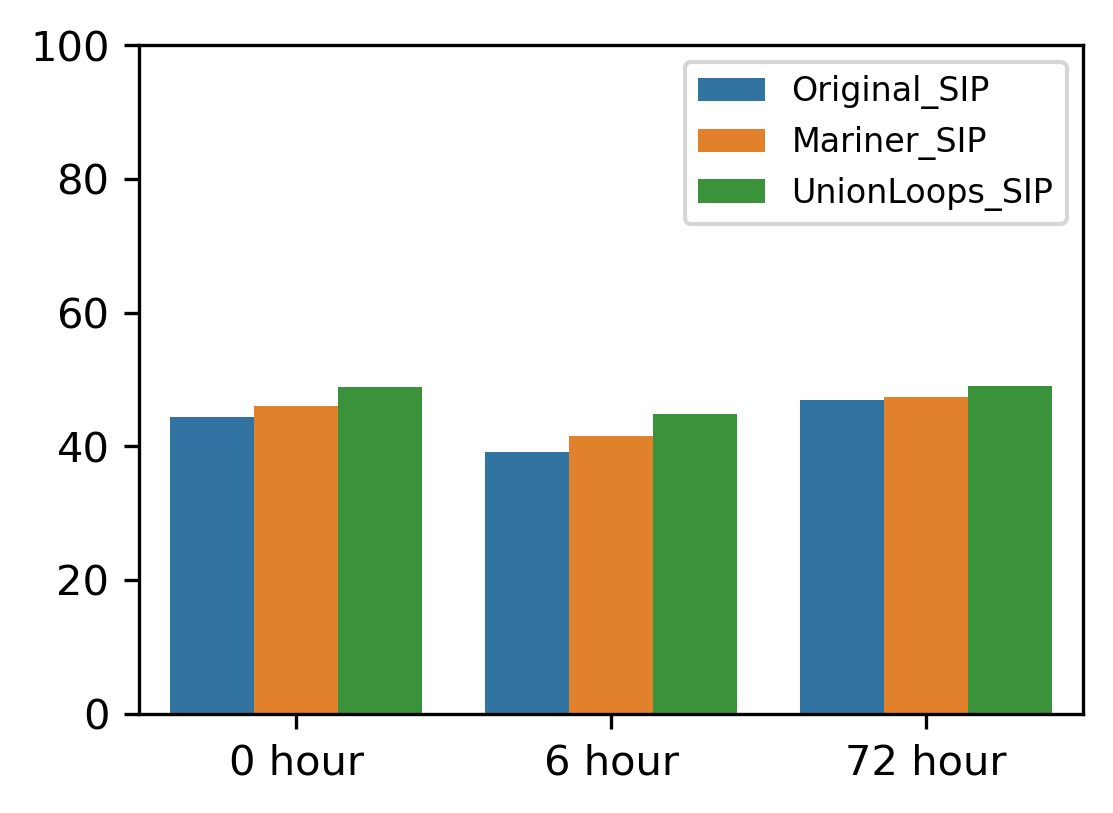

In [32]:
# CTCF
from scipy.stats import chi2_contingency

# Create the grouped bar plot
plt.figure(figsize=(4, 3), dpi=300)
ax = sns.barplot(x='condition', y='percent', hue='method', data=anchors_overlapped_with_CTCF_peaks, hue_order=methods, palette=['#1f77b4', '#ff7f0e', '#2ca02c'])

# Set custom x-tick labels
ax.set_xticklabels(['0 hour', '6 hour', '72 hour'])
ax.set_yticks(range(0, 101, 20))

# chi2 test (original_sip vs mariner_sip)
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
p_labels_original_sip_vs_mariner_sip=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_CTCF_peaks.loc[anchors_overlapped_with_CTCF_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_original_sip_vs_mariner_sip.append(p_label)

# chi2 test (mariner_sip vs unionloops_sip)
p_labels_mariner_sip_vs_unionloops_sip=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_CTCF_peaks.loc[anchors_overlapped_with_CTCF_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]], [df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_mariner_sip_vs_unionloops_sip.append(p_label)
    
# chi2 test (original_sip vs unionloops_sip)
p_labels_original_sip_vs_unionloops_sip=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_CTCF_peaks.loc[anchors_overlapped_with_CTCF_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_original_sip_vs_unionloops_sip.append(p_label)

# Show the plot
# plt.title('Percentage of 5kb anchors overlapped with CTCF CNR peaks', fontsize=10)
# Get the current legend and update its labels
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Original_SIP', 'Mariner_SIP', 'UnionLoops_SIP'], loc='upper right', fontsize=8)
# plt.text(0.65, 94, 'Chi-square test\n*: significantly different\nns: non-significantly different', ha='left', fontsize=8, bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.5'))

plt.tight_layout()
# plt.ylabel('Percentage')
plt.ylabel('')
plt.xlabel('')
plt.ylim(0, 100)

# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_S9/bar_plot_of_percentage_of_5kb_anchors_of_raw_sip_mariner_sip_and_unionloop_sip_overlapped_with_CTCF_CNR_peaks_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')

print(f'p_labels_original_sip_vs_mariner_sip (per time point): {p_labels_original_sip_vs_mariner_sip}')
print(f'p_labels_mariner_sip_vs_unionloops_sip (per time point): {p_labels_mariner_sip_vs_unionloops_sip}')
print(f'p_labels_original_sip_vs_unionloops_sip (per time point): {p_labels_original_sip_vs_unionloops_sip}')


p_labels_original_sip_vs_mariner_sip (per time point): ['*', 'ns']
p_labels_mariner_sip_vs_unionloops_sip (per time point): ['*', 'ns']
p_labels_original_sip_vs_unionloops_sip (per time point): ['*', 'ns']


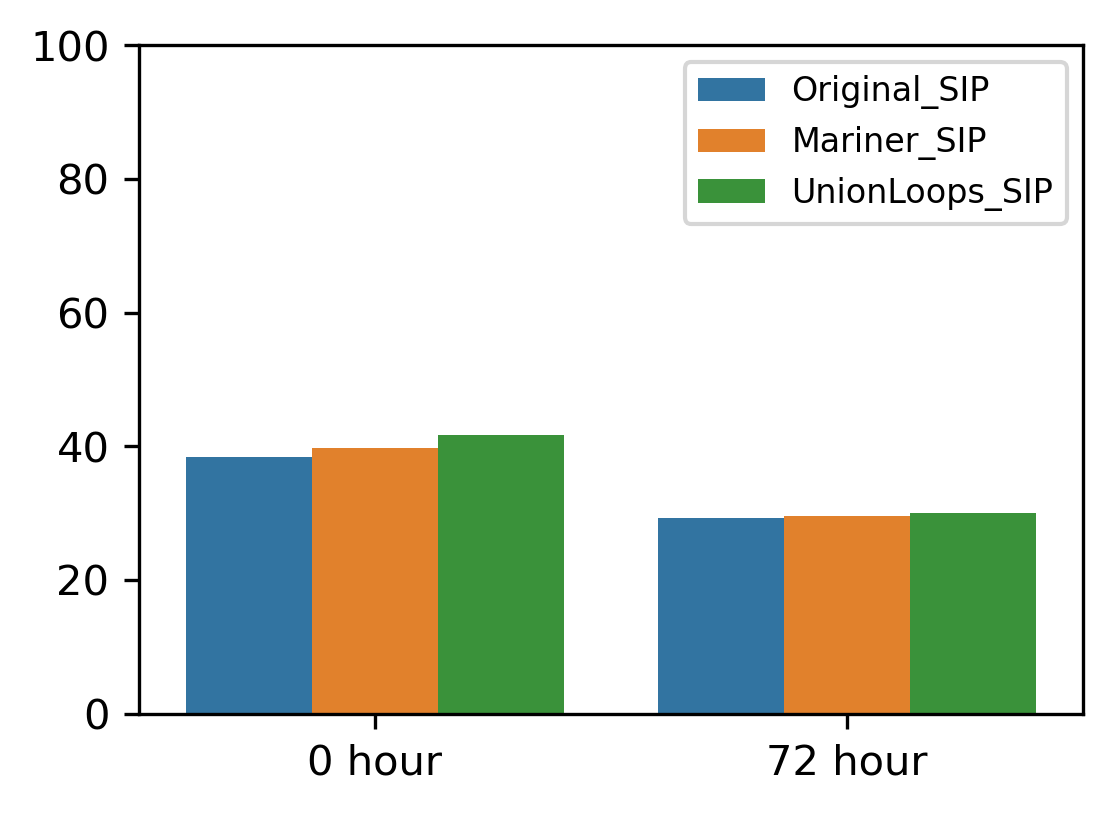

In [33]:
# rad21
from scipy.stats import chi2_contingency

# Create the grouped bar plot
plt.figure(figsize=(4, 3), dpi=300)
ax = sns.barplot(x='condition', y='percent', hue='method', data=anchors_overlapped_with_rad21_peaks, hue_order=methods, palette=['#1f77b4', '#ff7f0e', '#2ca02c'])

# Set custom x-tick labels
ax.set_xticklabels(['0 hour', '72 hour'])
ax.set_yticks(range(0, 101, 20))

# chi2 test (original_sip vs mariner_sip)
conditions=['K562_0000min',
            'K562_4320min']
p_labels_original_sip_vs_mariner_sip=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_rad21_peaks.loc[anchors_overlapped_with_rad21_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_original_sip_vs_mariner_sip.append(p_label)

# chi2 test (mariner_sip vs unionloops_sip)
p_labels_mariner_sip_vs_unionloops_sip=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_rad21_peaks.loc[anchors_overlapped_with_rad21_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]], [df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_mariner_sip_vs_unionloops_sip.append(p_label)
    
# chi2 test (original_sip vs unionloops_sip)
p_labels_original_sip_vs_unionloops_sip=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_rad21_peaks.loc[anchors_overlapped_with_rad21_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_original_sip_vs_unionloops_sip.append(p_label)

# Show the plot
# plt.title('Percentage of 5kb anchors overlapped with rad21 CNR peaks', fontsize=10)
# Get the current legend and update its labels
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Original_SIP', 'Mariner_SIP', 'UnionLoops_SIP'], loc='upper right', fontsize=8)
# plt.text(0.65, 94, 'Chi-square test\n*: significantly different\nns: non-significantly different', ha='left', fontsize=8, bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.5'))

plt.tight_layout()
# plt.ylabel('Percentage')
plt.ylabel('')
plt.xlabel('')
plt.ylim(0, 100)


# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_S9/bar_plot_of_percentage_of_5kb_anchors_of_raw_sip_mariner_sip_and_unionloop_sip_overlapped_with_Rad21_CNR_peaks_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')



print(f'p_labels_original_sip_vs_mariner_sip (per time point): {p_labels_original_sip_vs_mariner_sip}')
print(f'p_labels_mariner_sip_vs_unionloops_sip (per time point): {p_labels_mariner_sip_vs_unionloops_sip}')
print(f'p_labels_original_sip_vs_unionloops_sip (per time point): {p_labels_original_sip_vs_unionloops_sip}')


p_labels_original_sip_vs_mariner_sip (per time point): ['ns', '*', 'ns']
p_labels_mariner_sip_vs_unionloops (per time point): ['*', '*', '*']
p_labels_original_sip_vs_unionloops (per time point): ['*', '*', '*']


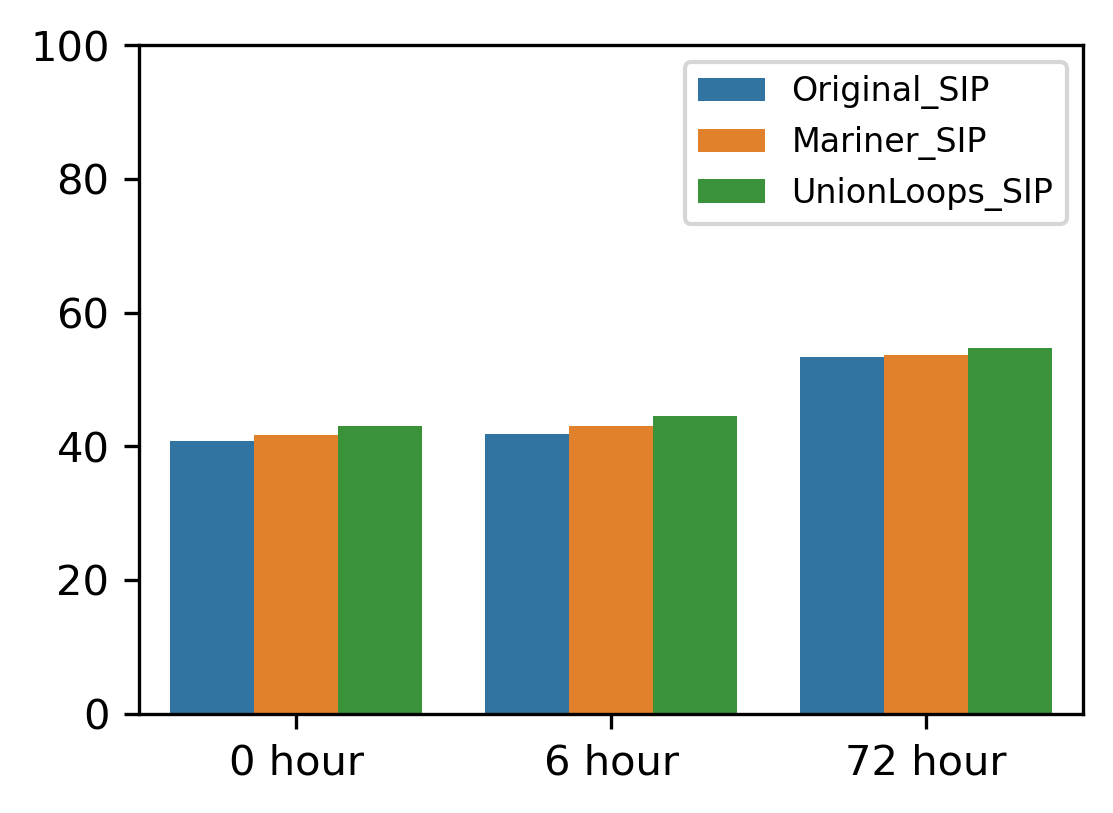

In [34]:
# atac
from scipy.stats import chi2_contingency

# Create the grouped bar plot
plt.figure(figsize=(4, 3), dpi=300)
ax = sns.barplot(x='condition', y='percent', hue='method', data=anchors_overlapped_with_atac_peaks, hue_order=methods, palette=['#1f77b4', '#ff7f0e', '#2ca02c'])

# Set custom x-tick labels
ax.set_xticklabels(['0 hour', '6 hour', '72 hour'])
ax.set_yticks(range(0, 101, 20))

# chi2 test (original_sip vs mariner_sip)
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
p_labels_original_sip_vs_mariner_sip=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_atac_peaks.loc[anchors_overlapped_with_atac_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_original_sip_vs_mariner_sip.append(p_label)

# chi2 test (mariner_sip vs unionloops_sip)
p_labels_mariner_sip_vs_unionloops_sip=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_atac_peaks.loc[anchors_overlapped_with_atac_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]], [df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_mariner_sip_vs_unionloops_sip.append(p_label)

# chi2 test (original_sip vs unionloops_sip)
p_labels_original_sip_vs_unionloops_sip=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_atac_peaks.loc[anchors_overlapped_with_atac_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_original_sip_vs_unionloops_sip.append(p_label)

# Show the plot
# plt.title('Percentage of 5kb anchors overlapped with atac CNR peaks', fontsize=10)
# Get the current legend and update its labels
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Original_SIP', 'Mariner_SIP', 'UnionLoops_SIP'], loc='upper right', fontsize=8)
# plt.text(0.65, 94, 'Chi-square test\n*: significantly different\nns: non-significantly different', ha='left', fontsize=8, bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.5'))

plt.tight_layout()
# plt.ylabel('Percentage')
plt.ylabel('')
plt.xlabel('')
plt.ylim(0, 100)


# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_S9/bar_plot_of_percentage_of_5kb_anchors_of_raw_sip_mariner_sip_and_unionloop_sip_overlapped_with_ATAC_Seq_peaks_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')


print(f'p_labels_original_sip_vs_mariner_sip (per time point): {p_labels_original_sip_vs_mariner_sip}')
print(f'p_labels_mariner_sip_vs_unionloops (per time point): {p_labels_mariner_sip_vs_unionloops_sip}')
print(f'p_labels_original_sip_vs_unionloops (per time point): {p_labels_original_sip_vs_unionloops_sip}')


## Original mustache loops VS UnionLoops-fine-tuned mustache loops.

In [ ]:
# Install mustache
# cd /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/mustache_loop_caller/

# git clone https://github.com/ay-lab/mustache
# conda env create -f ./mustache/environment.yml
# conda activate mustache

# mustache: v1.3.3


### Generate mustache loops

In [ ]:
conditions=['K562_0000min','K562_0360min','K562_4320min','MEGA']

clr_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/coolers/'

coolers = {'K562_0000min': clr_dir+'HIC_K562_0000min_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool',
           'K562_0360min': clr_dir+'HIC_K562_0360min_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool',
           'K562_4320min': clr_dir+'HIC_K562_4320min_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool',
           'MEGA': clr_dir+'HIC_K562_0000_0360_4320_biorep1_to_4__hg38.hg38.mapq_30.1000.mcool'
}

output_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/mustache_5kb/'
output_files={'K562_0000min': output_dir+'K562_0h_mustache_5kbLoops.txt',
              'K562_0360min': output_dir+'K562_6h_mustache_5kbLoops.txt',
              'K562_4320min': output_dir+'K562_72h_mustache_5kbLoops.txt',
              'MEGA': output_dir+'K562_Mega_mustache_5kbLoops.txt'
}


In [ ]:
# -pt 0.05: P-value threshold for the results in the final output. Default is 0.2.
for cond in conditions:
    cooler_path=coolers[cond]
    output=output_files[cond]
    
#     !bsub -q "long" -W 20:00 \
#         -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#         -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#         -n 4 -R "rusage[mem=8G]" \
#         -N -u jiangyuan.liu5@umassmed.edu \
#         "source ~/.bashrc && conda activate mustache && /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/mustache_loop_caller/mustache/mustache/mustache.py -f $cooler_path -o $output -r 5000 -pt 0.05 -p 4"


### Generate UnionLoops-fined-tuned mustache loops
UnionLoops (v1.1.0) now supports merging loops from multiple datasets generated by external loop callers.

In [18]:
# convert mustache loop files to bedpe format
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min',
            'MEGA']

mustache_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/mustache_5kb/'
# original_mustache
original_mustache_files={'K562_0000min': mustache_dir+'K562_0h_mustache_5kbLoops.txt',
                         'K562_0360min': mustache_dir+'K562_6h_mustache_5kbLoops.txt',
                         'K562_4320min': mustache_dir+'K562_72h_mustache_5kbLoops.txt',
                         'MEGA': mustache_dir+'K562_Mega_mustache_5kbLoops.txt'}

output_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/mustache_5kb/unionloops_v1.1.0/'
for cond in conditions:
    original_mustache_df = pd.read_csv(
        original_mustache_files[cond],
        usecols=range(6),
        header=0,
        sep='\t')
    original_mustache_df.columns = ['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']
#     original_mustache_df.to_csv(output_dir+os.path.basename(original_mustache_files[cond]).replace(".txt", ".bedpe"), sep="\t", index=False, header=False)


In [21]:
# generate loop path
mustache_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/mustache_5kb/'
loops = {'name': ['K562_0000min',
                  'K562_0360min',
                  'K562_4320min',
                  'MEGA'],
         'path': [mustache_dir + 'unionloops_v1.1.0/K562_0h_mustache_5kbLoops.bedpe',
                  mustache_dir + 'unionloops_v1.1.0/K562_6h_mustache_5kbLoops.bedpe',
                  mustache_dir + 'unionloops_v1.1.0/K562_72h_mustache_5kbLoops.bedpe',
                  mustache_dir + 'unionloops_v1.1.0/K562_Mega_mustache_5kbLoops.bedpe'
                 ]}
loops = pd.DataFrame.from_dict(loops)

# loops.to_csv(mustache_dir+'unionloops_v1.1.0/Mustache_loop_paths_of_Bond_et_al_2023.tsv', sep='\t', index=False, header=True)


In [ ]:
# Run unionloops pipeline
# cd /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/mustache_5kb/unionloops_v1.1.0
# bsub < run.sh


### Compare precision of original mustache loops VS UnionLoops-fine-tuned mustache loops

In [1]:
import pickle
import bioframe
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
from matplotlib import pyplot as plt

In [2]:
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']

mustache_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/mustache_5kb/'
# original_mustache
original_mustache_files={'K562_0000min': mustache_dir+'K562_0h_mustache_5kbLoops.txt',
                    'K562_0360min': mustache_dir+'K562_6h_mustache_5kbLoops.txt',
                    'K562_4320min': mustache_dir+'K562_72h_mustache_5kbLoops.txt'}

# UnionLoops_mustache
dots_file=mustache_dir+'unionloops_v1.1.0/results/Bond_et_al_2023_union_Mustache_loop_list_5kb.tsv'
dots_new=pd.read_csv(dots_file, sep='\t')[['chrom1','start1','end1','chrom2','start2','end2','sample_name']]
# remove MEGA only loops
dots_new=dots_new.loc[dots_new.sample_name != 'MEGA']

In [3]:
# intersect original mustache and unionloops fine-tuned loops
summary_loops={}
for cond in conditions:
    summary_loops[cond]={}
    # original mustache
    original_mustache_df = pd.read_csv(
        original_mustache_files[cond],
        usecols=range(6),
        header=0,
        sep='\t')
    original_mustache_df.columns = ['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']
    
    # unionloops mustache
    dots_new_df=dots_new.loc[dots_new.sample_name.str.contains(cond)]
    
    summary_loops[cond]['original_mustache']=original_mustache_df
    summary_loops[cond]['unionloops_mustache']=dots_new_df
    
    


In [4]:
# merged peak files CNR (two replicates)

CNR_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/cut_and_run/merged/'
ctcf_peak_file={
    'K562_0000min': CNR_dir+'MEGA_ChIP_CTCF_K562_WT_PMA_0_S_peaks.narrowPeak',
    'K562_0360min': CNR_dir+'MEGA_ChIP_CTCF_K562_WT_PMA_360_S_peaks.narrowPeak',
    'K562_4320min': CNR_dir+'MEGA_ChIP_CTCF_K562_WT_PMA_4320_S_peaks.narrowPeak'
}

# Note: K562_0360min does not have rad21 data
rad21_peak_file={
    'K562_0000min': CNR_dir+'MEGA_ChIP_Rad21_K562_WT_PMA_0_S_peaks.narrowPeak',
    'K562_4320min': CNR_dir+'MEGA_ChIP_Rad21_K562_WT_PMA_4320_S_peaks.narrowPeak'
}

atac_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/ATAC_Seq/merged/'
atac_peak_file={
    'K562_0000min': atac_dir+'MERGE_MEGA_ATAC_ATAC_K562_WT_PMA_0_S_peaks.narrowPeak',
    'K562_0360min': atac_dir+'MERGE_MEGA_ATAC_ATAC_K562_WT_PMA_360_S_peaks.narrowPeak',
    'K562_4320min': atac_dir+'MERGE_MEGA_ATAC_ATAC_K562_WT_PMA_4320_S_peaks.narrowPeak'
}


In [5]:
methods=['original_mustache',
         'unionloops_mustache']

all_anchors=[]
for cond in conditions:
    for method in methods:
        loops_df=summary_loops[cond][method][['chrom1','start1','end1','chrom2','start2','end2']].copy().reset_index(drop=True)
        anchor1=loops_df[['chrom1','start1','end1']].copy().set_axis(['chrom','start','end'], axis=1)
        anchor2=loops_df[['chrom2','start2','end2']].copy().set_axis(['chrom','start','end'], axis=1)
        anchors=pd.concat([anchor1, anchor2], ignore_index=True).drop_duplicates().reset_index(drop=True)
        anchors['condition']=cond
        anchors['method']=method
        all_anchors.append(anchors)
        
all_anchors=pd.concat(all_anchors, ignore_index=True)


In [6]:
import bioframe
import pandas as pd
import numpy as np

def calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors):
    anchors_overlapped_with_peaks={'condition': [],
                                   'method': [],
                                   'count': [],
                                   'total': [],
                                   'percent': []
                                  }

    for cond in conditions:
        for method in methods:
            anchors_overlapped_with_peaks['condition'].append(cond)
            anchors_overlapped_with_peaks['method'].append(method)
            anchors=all_anchors.loc[(all_anchors.condition == cond) & (all_anchors.method == method), ['chrom','start','end']]
            anchors_overlapped_with_peaks['total'].append(len(anchors))

            peak_df=pd.read_csv(peak_file[cond],sep='\t',header=None).iloc[:,:3]
            peak_df.columns=['chrom','start','end']
            overlapped_anchors=bioframe.overlap(anchors, peak_df, how='inner', suffixes=("","_"))[['chrom','start','end']].drop_duplicates().reset_index(drop=True)    
            anchors_overlapped_with_peaks['count'].append(len(overlapped_anchors))
            anchors_overlapped_with_peaks['percent'].append(100*len(overlapped_anchors)/len(anchors))

    anchors_overlapped_with_peaks=pd.DataFrame(anchors_overlapped_with_peaks)
    return anchors_overlapped_with_peaks
    

In [7]:
# CTCF
peak_file=ctcf_peak_file
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
anchors_overlapped_with_CTCF_peaks=calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors)

# Rad21
# No K562_0360min
peak_file=rad21_peak_file
conditions=['K562_0000min',
#             'K562_0360min',
            'K562_4320min']
anchors_overlapped_with_rad21_peaks=calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors)

# atac
peak_file=atac_peak_file
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
anchors_overlapped_with_atac_peaks=calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors)


In [8]:
anchors_overlapped_with_CTCF_peaks

,condition,method,count,total,percent
0,K562_0000min,original_mustache,7951,17845,44.555898
1,K562_0000min,unionloops_mustache,8617,17106,50.374138
2,K562_0360min,original_mustache,6342,14873,42.641027
3,K562_0360min,unionloops_mustache,7065,14254,49.565034
4,K562_4320min,original_mustache,10747,24293,44.239081
5,K562_4320min,unionloops_mustache,11237,22984,48.890533


In [9]:
anchors_overlapped_with_rad21_peaks

,condition,method,count,total,percent
0,K562_0000min,original_mustache,6930,17845,38.834407
1,K562_0000min,unionloops_mustache,7346,17106,42.943996
2,K562_4320min,original_mustache,6597,24293,27.155971
3,K562_4320min,unionloops_mustache,6771,22984,29.459624


In [10]:
anchors_overlapped_with_atac_peaks

,condition,method,count,total,percent
0,K562_0000min,original_mustache,7580,17845,42.476884
1,K562_0000min,unionloops_mustache,7817,17106,45.697416
2,K562_0360min,original_mustache,6762,14873,45.464936
3,K562_0360min,unionloops_mustache,6996,14254,49.080960
4,K562_4320min,original_mustache,12840,24293,52.854732
5,K562_4320min,unionloops_mustache,12669,22984,55.120954


p_labels_original_mustache_vs_unionloops_mustache (per time point): ['*', '*', '*']


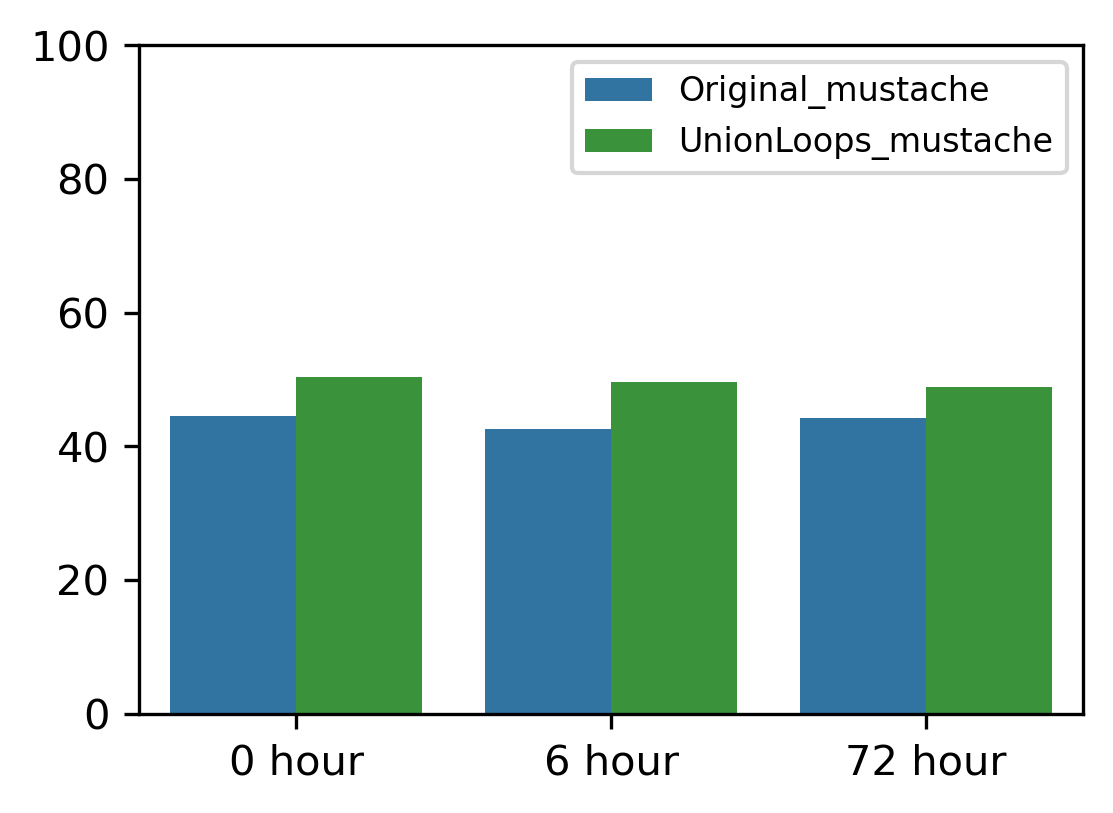

In [11]:
# CTCF
from scipy.stats import chi2_contingency

# Create the grouped bar plot
plt.figure(figsize=(4, 3), dpi=300)
ax = sns.barplot(x='condition', y='percent', hue='method', data=anchors_overlapped_with_CTCF_peaks, hue_order=methods, palette=['#1f77b4','#2ca02c'])

# Set custom x-tick labels
ax.set_xticklabels(['0 hour', '6 hour', '72 hour'])
ax.set_yticks(range(0, 101, 20))

# chi2 test (original_mustache vs unionloops_mustache)
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
p_labels_original_mustache_vs_unionloops_mustache=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_CTCF_peaks.loc[anchors_overlapped_with_CTCF_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_original_mustache_vs_unionloops_mustache.append(p_label)


# Show the plot
# plt.title('Percentage of 5kb anchors overlapped with CTCF CNR peaks', fontsize=10)
# Get the current legend and update its labels
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Original_mustache', 'UnionLoops_mustache'], loc='upper right', fontsize=8)
# plt.text(0.65, 94, 'Chi-square test\n*: significantly different\nns: non-significantly different', ha='left', fontsize=8, bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.5'))

plt.tight_layout()
# plt.ylabel('Percentage')
plt.ylabel('')
plt.xlabel('')
plt.ylim(0, 100)

# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_S9/bar_plot_of_percentage_of_5kb_anchors_of_raw_mustache_and_unionloop_mustache_overlapped_with_CTCF_CNR_peaks_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')

print(f'p_labels_original_mustache_vs_unionloops_mustache (per time point): {p_labels_original_mustache_vs_unionloops_mustache}')


p_labels_original_mustache_vs_unionloops_mustache (per time point): ['*', '*']


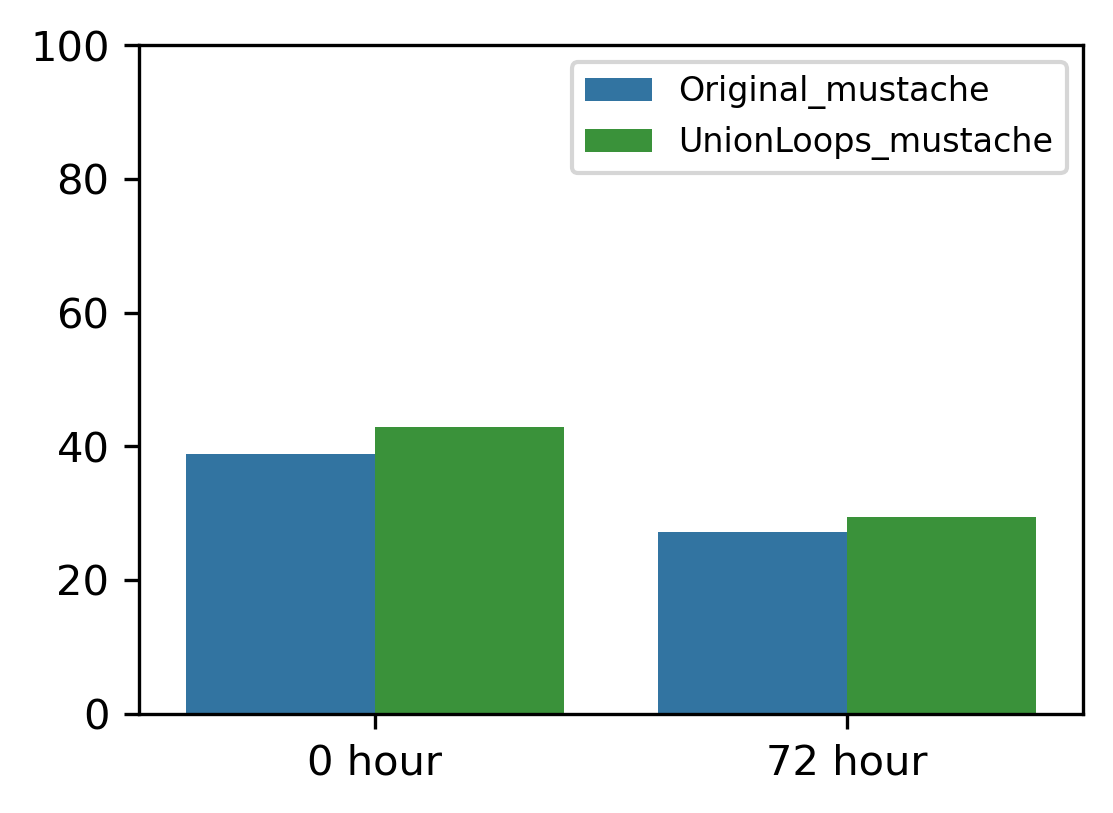

In [12]:
# Rad21
from scipy.stats import chi2_contingency

# Create the grouped bar plot
plt.figure(figsize=(4, 3), dpi=300)
ax = sns.barplot(x='condition', y='percent', hue='method', data=anchors_overlapped_with_rad21_peaks, hue_order=methods, palette=['#1f77b4','#2ca02c'])

# Set custom x-tick labels
ax.set_xticklabels(['0 hour', '72 hour'])
ax.set_yticks(range(0, 101, 20))

# chi2 test (original_mustache vs unionloops_mustache)
conditions=['K562_0000min',
            'K562_4320min']
p_labels_original_mustache_vs_unionloops_mustache=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_rad21_peaks.loc[anchors_overlapped_with_rad21_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_original_mustache_vs_unionloops_mustache.append(p_label)


# Show the plot
# plt.title('Percentage of 5kb anchors overlapped with rad21 CNR peaks', fontsize=10)
# Get the current legend and update its labels
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Original_mustache', 'UnionLoops_mustache'], loc='upper right', fontsize=8)
# plt.text(0.65, 94, 'Chi-square test\n*: significantly different\nns: non-significantly different', ha='left', fontsize=8, bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.5'))

plt.tight_layout()
# plt.ylabel('Percentage')
plt.ylabel('')
plt.xlabel('')
plt.ylim(0, 100)

# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_S9/bar_plot_of_percentage_of_5kb_anchors_of_raw_mustache_and_unionloop_mustache_overlapped_with_Rad21_CNR_peaks_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')

print(f'p_labels_original_mustache_vs_unionloops_mustache (per time point): {p_labels_original_mustache_vs_unionloops_mustache}')


p_labels_original_mustache_vs_unionloops_mustache (per time point): ['*', '*', '*']


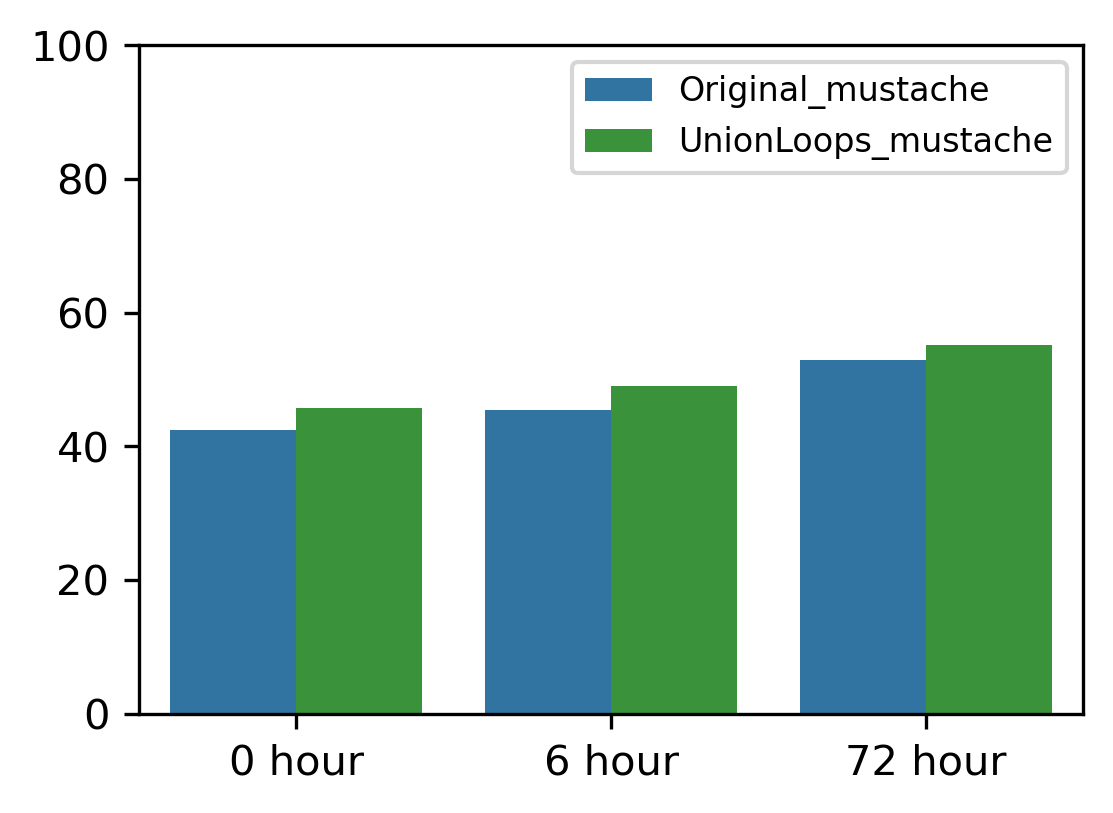

In [13]:
# atac
from scipy.stats import chi2_contingency

# Create the grouped bar plot
plt.figure(figsize=(4, 3), dpi=300)
ax = sns.barplot(x='condition', y='percent', hue='method', data=anchors_overlapped_with_atac_peaks, hue_order=methods, palette=['#1f77b4','#2ca02c'])

# Set custom x-tick labels
ax.set_xticklabels(['0 hour', '6 hour', '72 hour'])
ax.set_yticks(range(0, 101, 20))

# chi2 test (original_mustache vs unionloops_mustache)
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
p_labels_original_mustache_vs_unionloops_mustache=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_atac_peaks.loc[anchors_overlapped_with_atac_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_original_mustache_vs_unionloops_mustache.append(p_label)


# Show the plot
# plt.title('Percentage of 5kb anchors overlapped with atac CNR peaks', fontsize=10)
# Get the current legend and update its labels
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Original_mustache', 'UnionLoops_mustache'], loc='upper right', fontsize=8)
# plt.text(0.65, 94, 'Chi-square test\n*: significantly different\nns: non-significantly different', ha='left', fontsize=8, bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.5'))

plt.tight_layout()
# plt.ylabel('Percentage')
plt.ylabel('')
plt.xlabel('')
plt.ylim(0, 100)

# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_S9/bar_plot_of_percentage_of_5kb_anchors_of_raw_mustache_and_unionloop_mustache_overlapped_with_ATAC_Seq_peaks_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')

print(f'p_labels_original_mustache_vs_unionloops_mustache (per time point): {p_labels_original_mustache_vs_unionloops_mustache}')
